In [11]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

In [26]:
mri_path1 = r"C:\Users\hp\Downloads\IXI-T1\IXI378-IOP-0972-T1.nii.gz"
mri_path2 = r"C:\Users\hp\Downloads\IXI-T1\IXI425-IOP-0988-T1.nii.gz"
mri_path3 = r"C:\Users\hp\Downloads\IXI-T1\IXI371-IOP-0970-T1.nii.gz"

In [27]:
mri_img1 = nib.load(mri_path1)
mri_img2 = nib.load(mri_path2)
mri_img3 = nib.load(mri_path3)

In [28]:
mri_data1 = mri_img1.get_fdata()
mri_data2 = mri_img2.get_fdata()
mri_data3 = mri_img3.get_fdata()

In [29]:
# Print shape and data type
print("MRI shape:", mri_data1.shape)
print("MRI shape 2:", mri_data2.shape)
print("MRI shape 3:", mri_data3.shape)

MRI shape: (256, 256, 146)
MRI shape 2: (256, 256, 146)
MRI shape 3: (256, 256, 146)


In [30]:
# Compute the min and max intensity values
min_intensity1 = np.min(mri_data1)
max_intensity1 = np.max(mri_data1)

min_intensity2 = np.min(mri_data2)
max_intensity2 = np.max(mri_data2)

min_intensity3 = np.min(mri_data3)
max_intensity3 = np.max(mri_data3)

print(f"Pixel intensity range: {min_intensity1} to {max_intensity1}")
print(f"Pixel intensity range 2: {min_intensity2} to {max_intensity2}")
print(f"Pixel intensity range 3: {min_intensity3} to {max_intensity3}")

Pixel intensity range: 0.0 to 10111.0
Pixel intensity range 2: 0.0 to 13048.0
Pixel intensity range 3: 0.0 to 12226.0


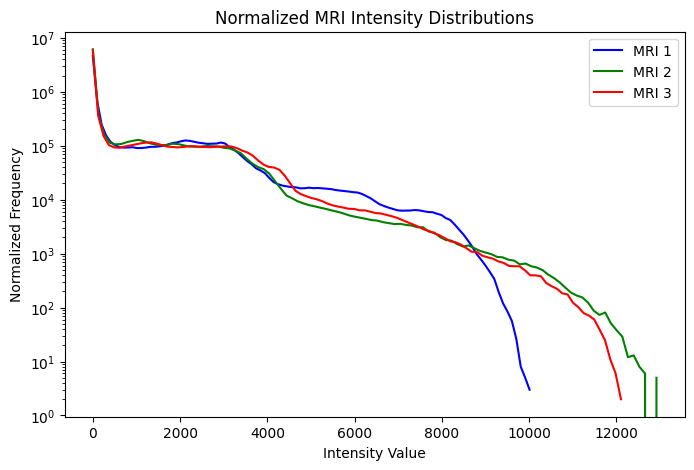

In [33]:
mri_paths = [mri_path1, mri_path2, mri_path3]
labels = ["MRI 1", "MRI 2", "MRI 3"]
colors = ["blue", "green", "red"]  # Different colors for each MRI

plt.figure(figsize=(8, 5))

# Loop through each MRI file and plot normalized histogram as a line
for i, mri_path in enumerate(mri_paths):
    mri_img = nib.load(mri_path)
    mri_data = mri_img.get_fdata().flatten()  # Flatten to 1D
    
    # Compute histogram and normalize
    hist, bins = np.histogram(mri_data, bins=100)  # Use density=True for normalization
    plt.plot(bins[:-1], hist, color=colors[i], label=labels[i])  # Line plot

# Formatting
plt.xlabel("Intensity Value")
plt.ylabel("Normalized Frequency")
plt.title("Normalized MRI Intensity Distributions")
plt.yscale("log")  # Log scale for better visibility
plt.legend()
plt.show()


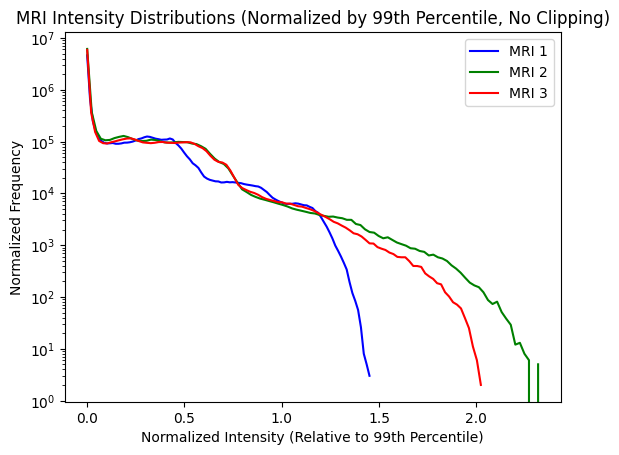

In [34]:
# Loop through each MRI file and plot normalized histogram as a line
for i, mri_path in enumerate(mri_paths):
    mri_img = nib.load(mri_path)
    mri_data = mri_img.get_fdata().flatten()  # Flatten to 1D
    
    # Normalize by 99th percentile (without clipping)
    percentile_99 = np.percentile(mri_data, 99)
    mri_data = mri_data / percentile_99  

    # Compute histogram
    hist, bins = np.histogram(mri_data, bins=100)
    plt.plot(bins[:-1], hist, color=colors[i], label=labels[i])  # Line plot

# Formatting
plt.xlabel("Normalized Intensity (Relative to 99th Percentile)")
plt.ylabel("Normalized Frequency")
plt.title("MRI Intensity Distributions (Normalized by 99th Percentile, No Clipping)")
plt.yscale("log")  # Log scale for better visibility
plt.legend()
plt.show()